# 09 — Refined hypothesis tests

Same Stage 10 statistical machinery; new measurements. Side-by-side original vs refined
δ values are **not** claimed commensurable — they show how conclusions change after
measurement repair.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh

ctx = nh.setup("09_refined_hypothesis_tests")
cfg = ctx.cfg
GATE = nh.effect_gate(cfg)
delta_freeze = cfg.section("stage10_delta_freeze")

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/09_refined_hypothesis_tests


In [2]:
frame = nh.load_refined_frame(cfg, "strict")
usable = frame[frame["analysable"].fillna(True)] if "analysable" in frame.columns else frame

features = {
    "H1_RLR": "RLR_emotional_vs_explicit",
    "H1_nonexplicit": "RAX_nonexplicit_affection",
    "H1_explicit": "RAX_explicit_sex",
    "H2_strict": "RAX_h2_strict",
    "H2_broad": "RAX_h2_broad",
    "H2_repair": "RAX_repair",
    "H3_RLR": "RLR_emotional_vs_material_security",
    "H3_emotional": "RAX_h3_emotional_side",
    "H3_material": "RAX_h3_material_side",
    "H3_status": "RAX_status_display",
    "H4_RLR": "RLR_protection_vs_control",
    "H4_protection": "RAX_h4_protection_side",
    "H4_possession": "RAX_h4_possession_side",
    "H5_RLR": "RLR_darkness_vs_tenderness",
    "H5_darkness": "RAX_relational_darkness",
    "H5_tenderness": "RAX_tenderness_core",
    "H5_external": "RAX_external_danger_crisis",
    "H6_RARC": "RARC",
    "H6_delta_rising": "DELTA_rising",
    "H6_delta_falling": "DELTA_falling",
}
cols = [c for c in features.values() if c in usable.columns]
effects = nh.cliffs_delta_table(usable, cols, n_boot=400, seed=42)
effects["label"] = effects["feature"].map({v: k for k, v in features.items()})
effects["verdict"] = [
    nh.verdict(r.cliffs_delta, r.ci_low, r.ci_high, GATE) for r in effects.itertuples()
]
display(effects.sort_values("cliffs_delta").round(4))
ctx.save_table(effects, "refined_hypothesis_effects")

,feature,cliffs_delta,ci_low,ci_high,magnitude,n_high,n_low,mean_high,mean_low,label,verdict
2,RAX_explicit_sex,-0.0616,-0.0831,-0.0392,negligible,5086,5389,0.0038,0.0055,H1_explicit,directional_only
9,RAX_status_display,-0.0295,-0.0526,-0.0084,negligible,5086,5389,0.0106,0.0109,H3_status,directional_only
11,RAX_h4_protection_side,-0.0212,-0.0422,0.0023,negligible,5086,5389,0.0105,0.0107,H4_protection,null
10,RLR_protection_vs_control,-0.0203,-0.0436,0.0012,negligible,5086,5389,3.5495,3.7397,H4_RLR,null
19,DELTA_falling,-0.0070,-0.0290,0.0151,negligible,5086,5389,0.0001,0.0001,H6_delta_falling,null
5,RAX_repair,0.0000,0.0000,0.0000,negligible,5086,5389,0.0000,0.0000,H2_repair,null
8,RAX_h3_material_side,0.0000,0.0000,0.0000,negligible,5086,5389,0.0000,0.0000,H3_material,null
18,DELTA_rising,0.0000,0.0000,0.0000,negligible,5086,5389,0.0000,0.0000,H6_delta_rising,null
13,RLR_darkness_vs_tenderness,0.0000,0.0000,0.0000,negligible,5086,5389,0.0000,0.0000,H5_RLR,null
14,RAX_relational_darkness,0.0000,0.0000,0.0000,negligible,5086,5389,0.0000,0.0000,H5_darkness,null


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/09_refined_hypothesis_tests/tables/refined_hypothesis_effects.csv  (20 rows)


## Side-by-side with Stage 10 primary δ

In [3]:
side = []
mapping = {
    "H1": ("H1_RLR", delta_freeze.get("H1")),
    "H2": ("H2_strict", delta_freeze.get("H2")),
    "H3": ("H3_RLR", delta_freeze.get("H3")),
    "H4": ("H4_RLR", delta_freeze.get("H4")),
    "H5": ("H5_RLR", delta_freeze.get("H5")),
    "H6": ("H6_RARC", delta_freeze.get("H6")),
}
for hyp, (lab, old) in mapping.items():
    row = effects[effects["label"] == lab]
    refined = float(row.iloc[0]["cliffs_delta"]) if len(row) else np.nan
    side.append(
        {
            "hypothesis": hyp,
            "original_delta": old,
            "refined_feature": lab,
            "refined_delta": refined,
            "refined_verdict": row.iloc[0]["verdict"] if len(row) else "missing",
        }
    )
side_df = pd.DataFrame(side)
display(side_df)
ctx.save_table(side_df, "stage10_vs_stage11_side_by_side")

,hypothesis,original_delta,refined_feature,refined_delta,refined_verdict
0,H1,-0.0290,H1_RLR,0.0614,directional_only
1,H2,0.0270,H2_strict,0.0330,directional_only
2,H3,-0.1460,H3_RLR,0.0609,directional_only
3,H4,0.0900,H4_RLR,-0.0203,null
4,H5,0.0120,H5_RLR,0.0000,null
5,H6,0.0440,H6_RARC,0.0070,null


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/09_refined_hypothesis_tests/tables/stage10_vs_stage11_side_by_side.csv  (6 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/09_refined_hypothesis_tests/figures/refined_effects_forest.png


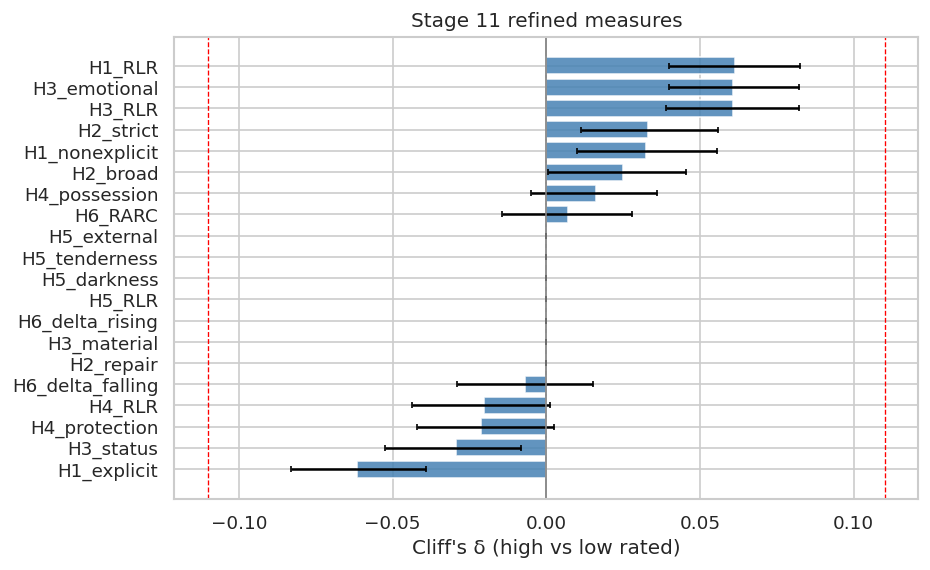

Effect gate |δ|≥0.11 with CI excluding 0. Components take precedence when they disagree with composites.


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = effects.dropna(subset=["cliffs_delta"]).sort_values("cliffs_delta")
y = np.arange(len(plot_df))
ax.barh(y, plot_df["cliffs_delta"], color="steelblue", alpha=0.85)
ax.errorbar(
    plot_df["cliffs_delta"],
    y,
    xerr=[
        plot_df["cliffs_delta"] - plot_df["ci_low"],
        plot_df["ci_high"] - plot_df["cliffs_delta"],
    ],
    fmt="none",
    ecolor="black",
    capsize=2,
)
ax.axvline(0, color="gray", lw=1)
ax.axvline(GATE, color="red", ls="--", lw=0.8)
ax.axvline(-GATE, color="red", ls="--", lw=0.8)
ax.set_yticks(y)
ax.set_yticklabels(plot_df["label"])
ax.set_xlabel("Cliff's δ (high vs low rated)")
ax.set_title("Stage 11 refined measures")
ctx.save_figure(fig, "refined_effects_forest")
plt.show()

print(
    f"Effect gate |δ|≥{GATE} with CI excluding 0. "
    "Components take precedence when they disagree with composites."
)